In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Import e exploração inicial

In [2]:
df = pd.read_csv("desafio_nps_fase_1.csv")
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [4]:
#Quantidade de nulos em cada coluna
df.isna().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

# Quais fatores parecem mais críticos para a satisfação?

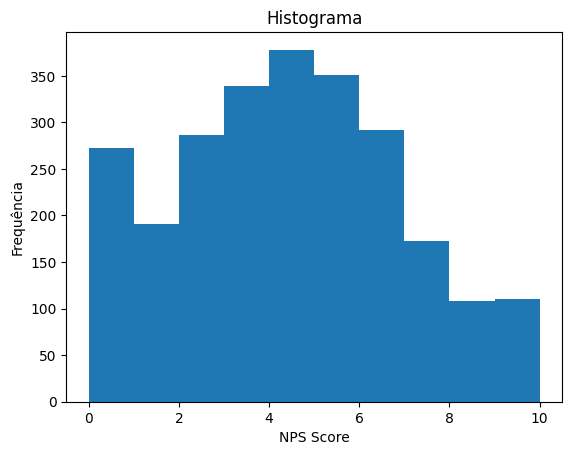

In [5]:
plt.hist(df['nps_score'])
plt.xlabel('NPS Score')
plt.ylabel('Frequência')
plt.title('Histograma')
plt.show()

In [6]:
#Criando classes para facilitar a analise dos clientes
df['nps_categoria'] = np.select(
    [
        df['nps_score'] <= 6
        ,df['nps_score'] <= 8
        ,df['nps_score'] <= 10
    ],
    [
        'Detrator'
        ,'Neutro'
        ,'Promotor'
    ],
    default= 'Verificar'
)

df["faixa_idade"] = pd.cut(df["customer_age"], bins=[0, 25, 35, 45, 55, 65, 100], labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])

df["faixa_tenure"] = pd.cut(df["customer_tenure_months"], bins=[0, 6, 12, 24, 36, 999], labels=["0-6m", "7-12m", "13-24m", "25-36m", "36m+"])

df["faixa_valor"] = pd.cut(df["order_value"], bins=[0, 100, 300, 600, 1000, 99999], labels=["0-100", "101-300", "301-600", "601-1000", "1000+"])


df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_categoria,faixa_idade,faixa_tenure,faixa_valor
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,0,4,6.9,0,3,6.5,Neutro,56-65,13-24m,101-300
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,0,10,2.4,0,3,0.0,Detrator,18-25,0-6m,301-600
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,4,5,4.8,0,7,1.5,Detrator,46-55,36m+,301-600
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,1,11,5.9,0,4,0.3,Detrator,46-55,36m+,301-600
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,1,0,6.1,0,3,7.9,Neutro,56-65,36m+,101-300


### Grande concentração de notas baixas.

In [7]:
qtds = df['nps_categoria'].value_counts()
df_perc = pd.DataFrame({
    'qtd': qtds,
    '%': qtds / qtds.sum() * 100
})
df_perc

,qtd,%
nps_categoria,,
Detrator,1851,74.04
Neutro,448,17.92
Promotor,201,8.04


# O que mais gera detratores?

##### A média de dias de atraso da entrega é cerca de 233% maior do que os Promotores e 81% maior do que os Neutros.
##### A média de número de contatos do cliente com o atendimento é cerca de 117% maior do que os Promotores e 50% maior do que os Neutros.
##### A média de reclamações registradas é 93% maior do que os Promotores e 55% maior do que os Neutros
##### A média de dias para resolução de problemas é 40% maior do que os Promotores e 20% maior do que os Neutros

In [8]:
df.groupby('nps_categoria').agg({
    'delivery_delay_days':'mean'
    ,'customer_service_contacts':'mean'
    ,'complaints_count':'mean'
    ,'resolution_time_days':'mean'
}).head()

,delivery_delay_days,customer_service_contacts,complaints_count,resolution_time_days
nps_categoria,,,,
Detrator,2.534306,1.694219,4.622907,5.793625
Neutro,1.395089,1.129464,2.986607,4.832589
Promotor,0.756219,0.781095,2.393035,4.104478


# Identificando o Ponto de Ruptura:

### Qualquer entrega que atrasa mesmo que 1 dia já coloca a maioria dos clientes no campo negativo. O prazo de entrega é crítico e pode afetar a percepção do cliente

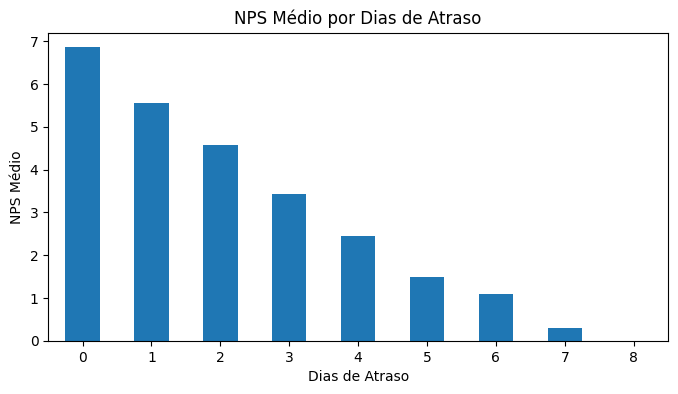

In [9]:
# Média do NPS por dias de atraso
nps_por_atraso = df.groupby("delivery_delay_days")["nps_score"].mean()

nps_por_atraso.plot(kind="bar", figsize=(8, 4))

plt.title("NPS Médio por Dias de Atraso")
plt.xlabel("Dias de Atraso")
plt.ylabel("NPS Médio")
plt.xticks(rotation=0)
plt.show()

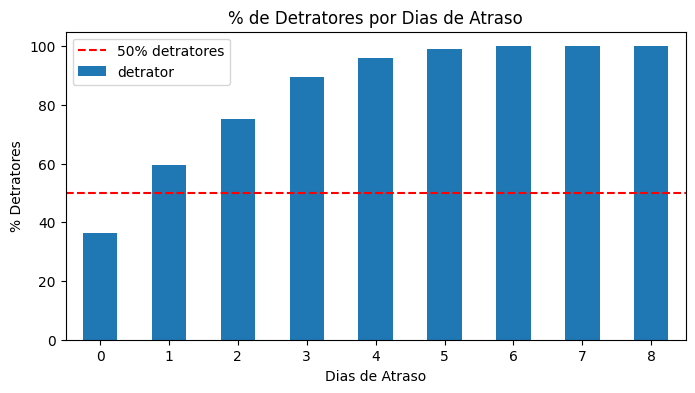

delivery_delay_days
0     36.5
1     59.7
2     75.4
3     89.7
4     95.9
5     99.1
6    100.0
7    100.0
8    100.0
Name: detrator, dtype: float64


In [10]:
# % de detratores por dia de atraso
pct_detratores = (
    df.assign(detrator = df["nps_categoria"] == "Detrator")
      .groupby("delivery_delay_days")["detrator"]
      .mean() * 100
)

pct_detratores.plot(kind="bar", figsize=(8, 4))

plt.axhline(50, color="red", linestyle="--",  label="50% detratores")
plt.title("% de Detratores por Dias de Atraso")
plt.xlabel("Dias de Atraso")
plt.ylabel("% Detratores")
plt.xticks(rotation=0)
plt.legend()
plt.show()

print(pct_detratores.round(1))

# Tipo de cliente tende a ter NPS mais alto ou mais baixo

#### Atraso é o principal indicador +205% de atraso em quem não recompra

#### Contatos com suporte: +98.8%

#### Reclamações: +78.5% 

#### Clientes com problemas não resolvidos rapidamente, entra em loop de contato -> aumenta desgaste -> reduz recompra

#### Tempo de resolução +36.7% 

In [11]:
#Campos núméricos que influenciam a nota do NPS
correlacoes = df.corr(numeric_only=True)["nps_score"].drop("nps_score").sort_values()
print(correlacoes)

delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
freight_value               -0.041087
customer_age                -0.009936
customer_tenure_months      -0.009711
delivery_time_days           0.000925
items_quantity               0.011468
customer_id                  0.015162
order_id                     0.015162
payment_installments         0.023718
discount_value               0.025104
delivery_attempts            0.027680
order_value                  0.036990
csat_internal_score          0.563952
repeat_purchase_30d          0.570324
Name: nps_score, dtype: float64


In [12]:
cores = ["#E74C3C", "#F39C12", "#2ECC71"]  # Detrator, Neutro, Promotor
ordem = ["Detrator", "Neutro", "Promotor"]

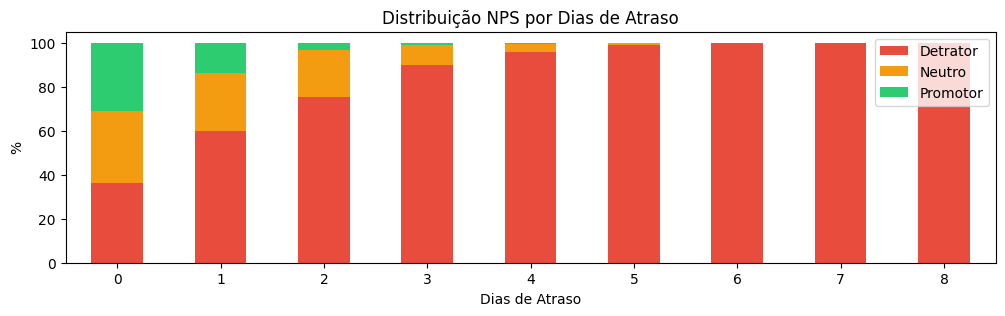

In [13]:
tabela = df.groupby("delivery_delay_days")["nps_categoria"] \
           .value_counts(normalize=True).unstack()[ordem] * 100

tabela.plot(kind="bar", stacked=True, figsize=(12, 3), color=cores)
plt.title("Distribuição NPS por Dias de Atraso")
plt.xlabel("Dias de Atraso")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.show()

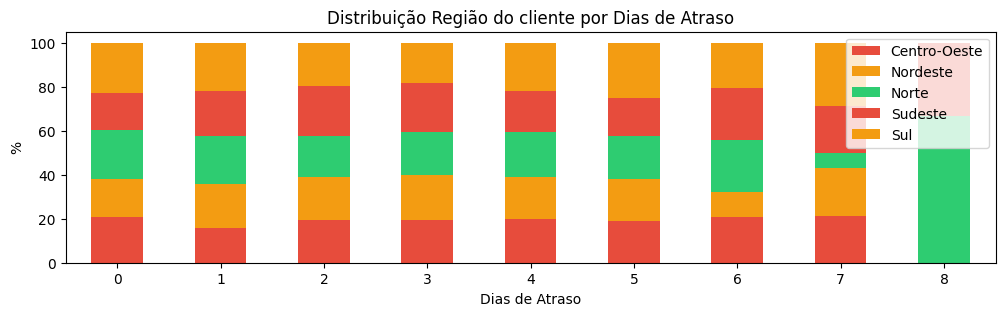

In [14]:
tabela = df.groupby("delivery_delay_days")["customer_region"] \
           .value_counts(normalize=True).unstack() * 100

tabela.plot(kind="bar", stacked=True, figsize=(12, 3), color=cores)
plt.title("Distribuição Região do cliente por Dias de Atraso")
plt.xlabel("Dias de Atraso")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.show()

In [15]:
df.groupby("delivery_delay_days")['delivery_delay_days'].count()

delivery_delay_days
0    277
1    615
2    646
3    525
4    270
5    116
6     34
7     14
8      3
Name: delivery_delay_days, dtype: int64

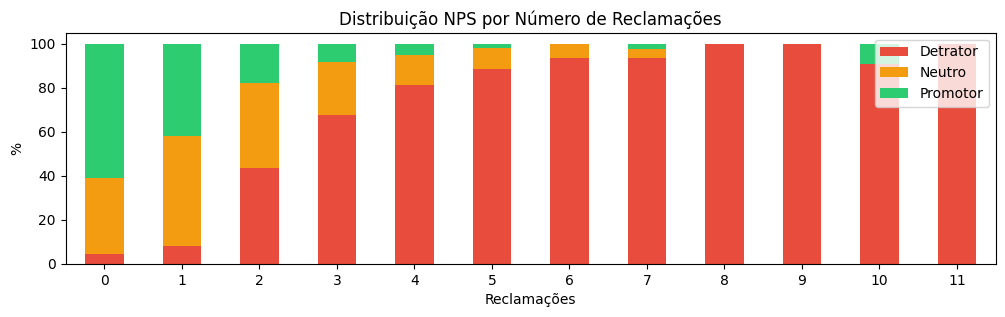

In [16]:
tabela = df.groupby("complaints_count")["nps_categoria"] \
           .value_counts(normalize=True).unstack()[ordem] * 100

tabela.plot(kind="bar", stacked=True, figsize=(12, 3), color=cores)
plt.title("Distribuição NPS por Número de Reclamações")
plt.xlabel("Reclamações")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.show()

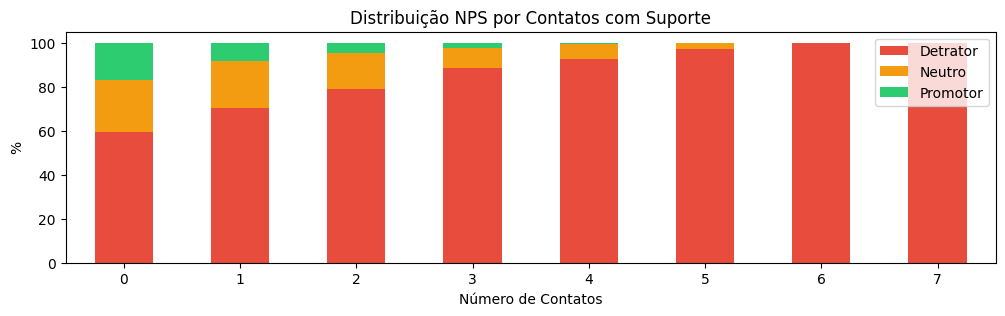

In [17]:
tabela = df.groupby("customer_service_contacts")["nps_categoria"] \
           .value_counts(normalize=True).unstack()[ordem] * 100

tabela.plot(kind="bar", stacked=True, figsize=(12, 3), color=cores)
plt.title("Distribuição NPS por Contatos com Suporte")
plt.xlabel("Número de Contatos")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.show()

In [18]:
#Média de dias para entrega
df['delivery_time_days'].mean()

np.float64(8.022)

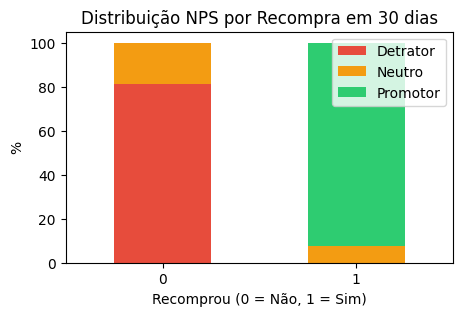

In [19]:
tabela = df.groupby("repeat_purchase_30d")["nps_categoria"] \
           .value_counts(normalize=True).unstack()[ordem] * 100

tabela.plot(kind="bar", stacked=True, figsize=(5, 3), color=cores)
plt.title("Distribuição NPS por Recompra em 30 dias")
plt.xlabel("Recomprou (0 = Não, 1 = Sim)")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.show()

In [20]:
df.groupby("repeat_purchase_30d")[["delivery_delay_days", "complaints_count", "customer_service_contacts", "resolution_time_days"]].mean().round(2)

,delivery_delay_days,complaints_count,customer_service_contacts,resolution_time_days
repeat_purchase_30d,,,,
0,2.32,4.32,1.59,5.62
1,0.76,2.42,0.80,4.11


#### Atraso é o principal indicador +205% de atraso em quem não recompra

#### Contatos com suporte: +98.8%

#### Reclamações: +78.5% 

#### Clientes com problemas não resolvidos rapidamente, entra em loop de contato → aumenta desgaste → reduz recompra

#### Tempo de resolução +36.7% 

In [21]:
##Taxa de recompra projetada (Para ficar em linha com o benchmark)

taxa_30d = df["repeat_purchase_30d"].mean() * 100
taxa_projetada = taxa_30d * (127 / 30)
print(f"Taxa 30d: {taxa_30d}%")
print(f"Taxa projetada 127d: {taxa_projetada:}%")

Taxa 30d: 8.72%
Taxa projetada 127d: 36.91466666666667%


In [22]:
df["csat_internal_score"].mean()

np.float64(2.9416)

In [23]:
#CSAT interno
print(f"Média: {df['csat_internal_score'].mean()}") #--29,4%
print(f"Mediana: {df['csat_internal_score'].median()}")
print(f"Mínimo: {df['csat_internal_score'].min()}")
print(f"Máximo: {df['csat_internal_score'].max()}")

Média: 2.9416
Mediana: 2.8
Mínimo: 0.0
Máximo: 10.0
